# MMC Chatbot — Responses (User Profile) EDA

Exploratory data analysis of `Base de datos respuestas Sami_060526.xlsx` (~240 user interaction records).

**What is this?** *Sami* is a WhatsApp chatbot that supports migrants in Colombia. Every time someone uses it, the conversation captures a profile of who they are and what they need. This notebook turns those ~240 interaction records into a portrait of Sami's users — and is the companion to the **MEAL feedback notebook**, which covers how satisfied those users are.

**The story this notebook tells.** We build the picture from the ground up:

1. **What data do we have, and is it clean?** (Sections 1–2) — loading, cleaning messy free-text fields, and checking completeness.
2. **Who are the users?** (Section 3) — nationality, gender, age, and care responsibilities.
3. **Where are they?** (Section 4) — which cities, how settled, mapped across Colombia.
4. **Where are they coming from and going to?** (Section 5) — the migration journey.
5. **How do they use the chatbot?** (Section 6) — topics asked, depth of use, and usage over time.
6. **What patterns emerge when we combine these?** (Section 7) — cross-cuts between demographics, geography, and engagement.

---

### How to read this notebook

Every section opens with a plain-language summary — **What this shows** and **Why it matters** — that needs no technical background. Where a chart or calculation involves a non-obvious choice (a cleaning rule, a colour scale, a normalization step), a short **Technical note** explains it for readers who want the detail. You can follow the narrative top-to-bottom without reading any code.

> **Technical note — survey data, not a census.** These are self-reported answers from people who chose to engage with the chatbot, so the user base described here reflects *who reached Sami*, not the migrant population of Colombia as a whole. Many fields are free-text and required cleaning (documented in Section 1); several are conditional and legitimately mostly-empty (explained in Section 2).

In [ ]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import seaborn as sns
import missingno as msno

# ---- Blue gradient palette (light -> dark) --------------------------------
# This notebook uses ONLY this monochrome blue ramp for every data mark
# (bars, lines, markers, fills, the map). Black text and a white background
# are kept for legibility -- they are neutrals, not competing hues.
BLUES = ['#DFE3F0', '#C5CFEB', '#A2B4E5', '#90A6E1', '#7692DC', '#6D8BDB']

NEGRO = '#000000'   # text, axes, edges
CIELO = '#FFFFFF'   # figure / axes background

# Semantic aliases so every existing chart draws from the same ramp.
AGUA_LIGHT   = BLUES[0]
AGUA_MID     = BLUES[2]
AGUA         = BLUES[4]   # primary single-series color
ARBOL        = BLUES[3]
AMEBA        = BLUES[1]
HONGO        = BLUES[0]   # map landmass fill — lightest so darker markers pop
MADERA       = BLUES[5]   # darkest — mean / contrast lines
MADERA_MID   = BLUES[4]
ARBOL_LIGHT  = BLUES[1]
MADERA_LIGHT = BLUES[0]

plt.rcParams.update({
    'figure.facecolor': CIELO,
    'axes.facecolor': CIELO,
    'axes.edgecolor': NEGRO,
    'text.color': NEGRO,
    'axes.labelcolor': NEGRO,
    'xtick.color': NEGRO,
    'ytick.color': NEGRO,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Fixed sequence used to give every bar of a categorical bar/barh chart a
# distinct shade of the blue ramp. Ordered so adjacent bars alternate
# dark/light and stay distinguishable within one hue family. `bar_colors(n)`
# cycles through it, repeating if a chart has more bars than colors.
BAR_PALETTE = [BLUES[5], BLUES[2], BLUES[0], BLUES[4], BLUES[1], BLUES[3]]


def bar_colors(n):
    """Return a list of n colors, cycling through BAR_PALETTE."""
    return [BAR_PALETTE[i % len(BAR_PALETTE)] for i in range(n)]


## 1. Data Load

**What this shows:** The raw responses sheet loaded into a clean table, plus the handful of cleaning steps the rest of the notebook depends on. After this step we know the dataset's size, columns, and types in a usable form.

**Why it matters:** This survey is full of real-world messiness — a stray spreadsheet artifact row, "Other" answers typed as free text, and one field (`City_duration`) where ~20 different spellings all mean the same five things. If we charted the raw data, the same answer would show up as several different bars. Cleaning here means every later section counts like-for-like.

> **Technical note.** Four cleaning steps are applied:
> - **Drop a spreadsheet artifact row** — one row has no `Name` or real user data, just a stray `Questions per user = 388` value; it's removed before any analysis.
> - **Merge "Other" free-text into its parent field** — `city_display` and `nationality_display` fall back to the `*_other` free-text whenever the main option was "Otra"/blank.
> - **Exclude junk nationalities** — two responses typed "3"/"4" instead of a country (likely accidental form input); `nationality_clean` filters them out.
> - **Normalize residency duration** — `DURATION_MAP` collapses the ~20 free-text variants of `City_duration` (e.g. "2 años", "8años", "5 anos" → *Más de 1 año*) into 5 standard ranges, plus *No especifica* for entries that aren't durations at all (e.g. "Vendo", "Santuario").

In [48]:
DATA_PATH = '../data_&_docs/Base de datos respuestas Sami_060526.xlsx'

df = pd.read_excel(DATA_PATH, sheet_name='mmc bot - responses', header=2)
df = df.dropna(how='all').reset_index(drop=True)

# One row has no Name, Timestamp, or any other field except a stray
# "Questions per user" = 388 value -- it is a spreadsheet artifact, not a
# real user interaction, so drop it before any analysis.
df = df[df['Name'].notna()].reset_index(drop=True)

df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Questions per user'] = pd.to_numeric(df['Questions per user'], errors='coerce')

# Consolidate _other columns: fill with free-text entry when main option is NaN/"Otra"
df['city_display'] = df.apply(
    lambda r: r['City_other'] if r['City'] == 'Otra' else r['City'], axis=1
)
df['nationality_display'] = df.apply(
    lambda r: r['Nationality_other'] if pd.isna(r['Nationality']) else r['Nationality'], axis=1
)

# A couple of "Nationality_other" free-text answers ("3", "4") are not
# nationalities -- almost certainly accidental numeric input on the form.
# `nationality_clean` excludes them so they don't show up as fake countries.
INVALID_NATIONALITIES = {'3', '4'}
df['nationality_clean'] = df['nationality_display'].where(
    ~df['nationality_display'].astype(str).isin(INVALID_NATIONALITIES)
)

# City_duration is a free-text field with ~20 spelling/format variants of
# the same 5 underlying duration ranges (e.g. "2 años", "8años", "5 anos"
# all mean "more than 1 year"). DURATION_MAP normalizes every observed
# value into one of 5 standard ranges, plus "No especifica" for entries
# that don't describe a duration at all (e.g. "Vendo", "Santuario").
DURATION_ORDER = [
    'Menos de 1 mes', 'Entre 1 y 3 meses', 'Entre 4 y 6 meses',
    'Entre 7 meses y 1 año', 'Más de 1 año', 'No especifica',
]
DURATION_MAP = {
    'Más de 1 año': 'Más de 1 año',
    'Menos de 1 mes': 'Menos de 1 mes',
    'Entre 1 y 3 meses': 'Entre 1 y 3 meses',
    'Entre 7 meses y 1 año': 'Entre 7 meses y 1 año',
    'Entre 4 y 6 meses': 'Entre 4 y 6 meses',
    '2 años': 'Más de 1 año',
    '15 días': 'Menos de 1 mes',
    '8 años': 'Más de 1 año',
    '5 años': 'Más de 1 año',
    '3 años': 'Más de 1 año',
    'Ya tengo una semana': 'Menos de 1 mes',
    '7 años': 'Más de 1 año',
    'Vendo': 'No especifica',
    '8ños': 'Más de 1 año',
    '7 años 9 meses': 'Más de 1 año',
    '5 anos': 'Más de 1 año',
    '2 año': 'Más de 1 año',
    'Santuario': 'No especifica',
    'Acabo de llegar': 'Menos de 1 mes',
    '3 meses': 'Entre 1 y 3 meses',
    'Norte de Santander': 'No especifica',
}
df['city_duration_clean'] = df['City_duration'].map(DURATION_MAP)

print(f"Shape: {df.shape}")
df.dtypes


Shape: (239, 32)


Name                                   str
Subitems                           float64
Timestamp              datetime64[us, UTC]
Consent                                str
Nationality                            str
Nationality_other                      str
City                                   str
City Location                      float64
City_other                             str
City_duration                          str
Gender                                 str
Gender_other                           str
Age                                float64
Minors                                 str
Away_duration                          str
Prev_country                       float64
Prev_country_other                     str
Destination                            str
Destination_other                      str
Destination_Country                    str
Messages                               str
Survey sent                            str
Chat_summary                           str
Summarize  

In [49]:
df.head(3)

,Name,Subitems,Timestamp,Consent,Nationality,Nationality_other,City,City Location,City_other,City_duration,...,Chat_summary,Summarize,Age Ranges,Questions per user,Text,Text 1,city_display,nationality_display,nationality_clean,city_duration_clean
0,whatsapp:+573001188778,NaN,2026-03-25 13:43:06.306000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Más de 1 año,...,NaN,NaN,50 and above,0.0,NaN,Summarize the intent of the question,Medellín,Venezuela,Venezuela,Más de 1 año
1,whatsapp:+573002990649,NaN,2026-03-25 13:46:42.884000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Más de 1 año,...,humanitarian assistance,NaN,36-50,1.0,I am a migrant woman residing in Medellín and ...,Solicitud de ayuda económica para cubrir gasto...,Medellín,Venezuela,Venezuela,Más de 1 año
2,whatsapp:+573106332924,NaN,2026-03-25 14:01:12.940000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Más de 1 año,...,NaN,NaN,36-50,0.0,NaN,Summarize the intent of the question,Medellín,Venezuela,Venezuela,Más de 1 año


## 2. Data Quality

**What this shows:** How complete each column is, and how many *unique* users the dataset really represents once duplicates are accounted for.

**Why it matters:** Before trusting any column, we need to know how much of it is actually filled in. The catch: high missingness isn't always a problem. Many fields are **conditional by design** — for example, the `*_other` fields only apply to people who picked "Otra," so they're *supposed* to be empty for everyone else. This section separates "empty because optional" from "empty because unreliable," so later sections only lean on columns that can bear the weight.

> **Technical note.** The `missingno` bar shows per-column completeness; the printed table lists exact missingness rates sorted high-to-low. Conditional `*_other` fields are expected near the top and should not be read as data-quality issues. We also report duplicate `Name` entries and the unique-user count, so headline totals aren't inflated by repeat rows.

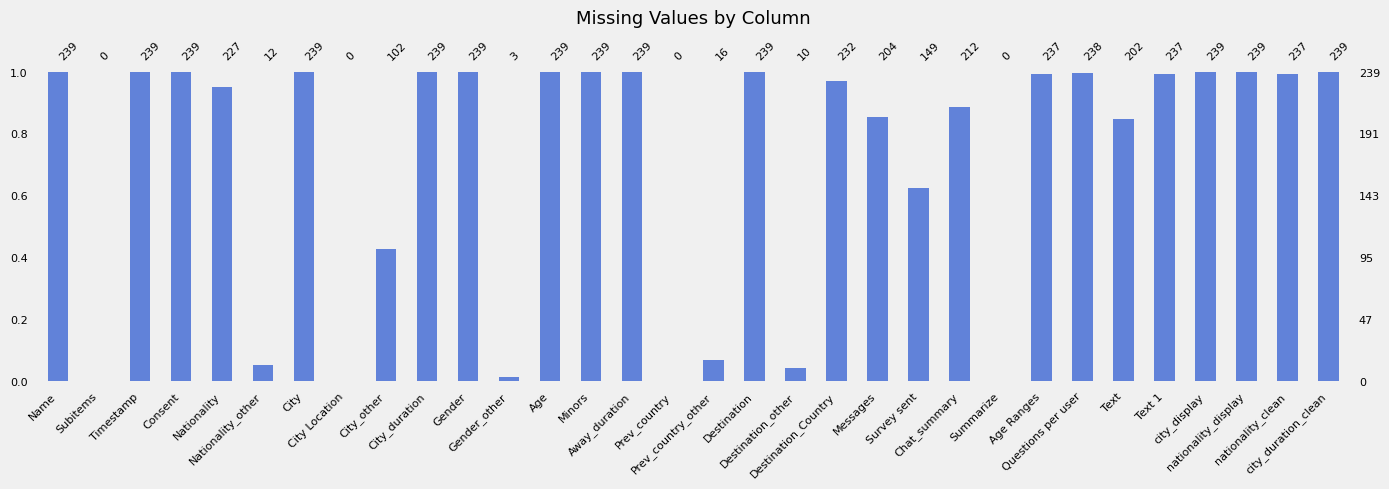

In [50]:
fig, ax = plt.subplots(figsize=(14, 5))
msno.bar(df, ax=ax, color=AGUA, fontsize=8)
ax.set_title('Missing Values by Column', fontsize=13, pad=12)
plt.tight_layout()
plt.show()


In [51]:
missing = df.isnull().mean().sort_values(ascending=False)
print("Missingness rate:")
print(missing[missing > 0].map(lambda x: f"{x:.1%}").to_string())
print(f"\nDuplicate Name entries: {df['Name'].duplicated().sum()}")
print(f"Unique users:            {df['Name'].nunique()}")
print(f"Date range:              {df['Timestamp'].min().date()} → {df['Timestamp'].max().date()}")


Missingness rate:
Subitems               100.0%
City Location          100.0%
Prev_country           100.0%
Summarize              100.0%
Gender_other            98.7%
Destination_other       95.8%
Nationality_other       95.0%
Prev_country_other      93.3%
City_other              57.3%
Survey sent             37.7%
Text                    15.5%
Messages                14.6%
Chat_summary            11.3%
Nationality              5.0%
Destination_Country      2.9%
Text 1                   0.8%
nationality_clean        0.8%
Age Ranges               0.8%
Questions per user       0.4%

Duplicate Name entries: 6
Unique users:            233
Date range:              2026-03-25 → 2026-05-06


## 3. Demographics

**What this shows:** A profile of *who* uses the chatbot — nationality, gender, age (as both a distribution and grouped ranges), and how many users are responsible for minors in their care.

**Why it matters:** Knowing the audience shapes everything else the program does, from the language and tone Sami uses to the services it points people toward. A user base skewed toward families with children, for instance, has very different needs from one of mostly single adults — and outreach, content, and partner referrals should reflect that.

> **Technical note.** Nationality uses `nationality_clean` (the cleaned field from Section 1, with the "3"/"4" junk values removed). For gender, the "Otro" category is expanded by printing the underlying `Gender_other` free-text, so it isn't left as an unexplained catch-all. Age is shown as a histogram **and** a box plot together — the histogram reveals the shape of the distribution while the box plot pinpoints the median, the middle 50%, and any outliers.

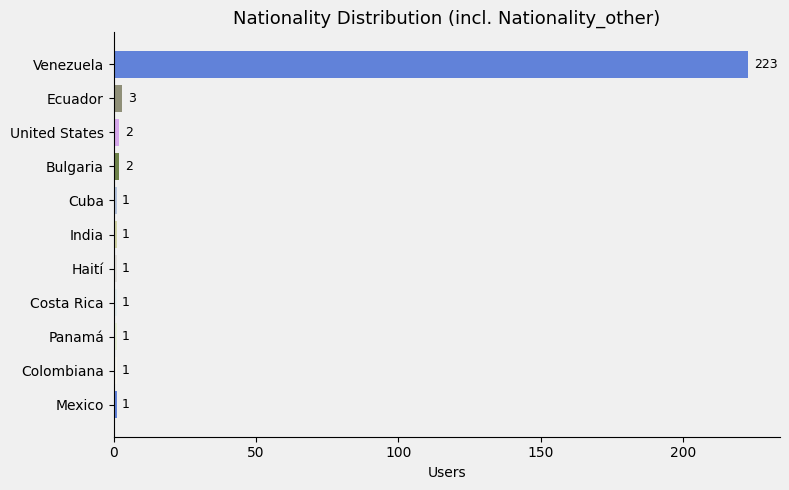

In [52]:
# Question: which nationalities use the chatbot, and in what proportion?
# `nationality_clean` (built in section 1) excludes the 2 responses that
# entered "3"/"4" instead of an actual nationality.
nat = df['nationality_clean'].value_counts().head(12)
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(nat.index[::-1], nat.values[::-1], color=bar_colors(len(nat))[::-1])
ax.bar_label(bars, padding=4, color=NEGRO, fontsize=9)
ax.set_xlabel('Users')
ax.set_title('Nationality Distribution (incl. Nationality_other)', fontsize=13)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()


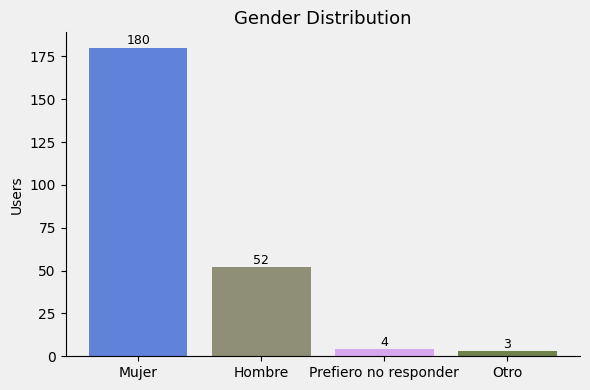

'Otro' breakdown (3 of 239 users):
  - 'Mujer'
  - 'Soy una mujer trans'
  - 'transgenero'


In [53]:
# Question: how is the user base distributed across genders?
gender = df['Gender'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(gender.index, gender.values, color=bar_colors(len(gender)))
ax.set_ylabel('Users')
ax.set_title('Gender Distribution', fontsize=13)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            int(bar.get_height()), ha='center', va='bottom', fontsize=9)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()

# Question: what does "Otro" actually mean here? Gender_other holds the
# free-text answer each "Otro" respondent typed, so we surface it directly
# rather than leaving "Otro" as an unexplained catch-all.
otro_detail = df.loc[df['Gender'] == 'Otro', 'Gender_other'].dropna()
print(f"'Otro' breakdown ({len(otro_detail)} of {len(df)} users):")
for text in otro_detail:
    print(f"  - {text!r}")


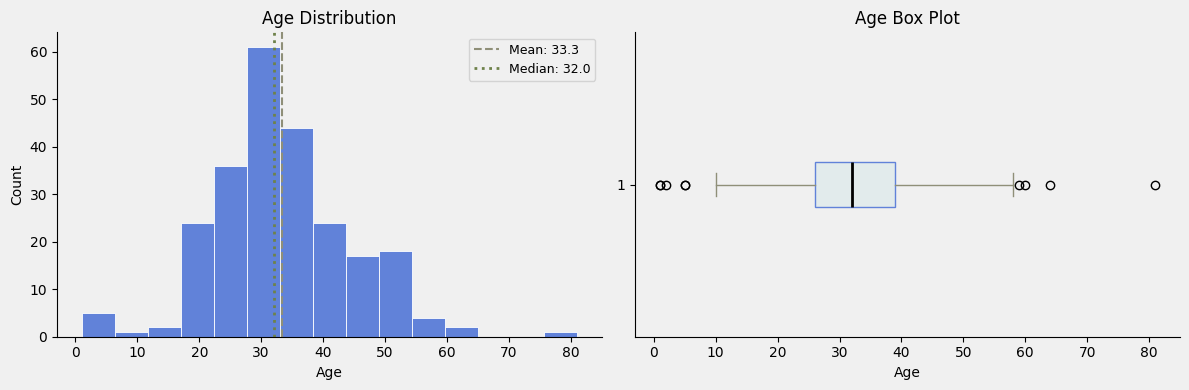

count    239.0
mean      33.3
std       11.2
min        1.0
25%       26.0
50%       32.0
75%       39.0
max       81.0


In [54]:
# Question: what does the age profile of users look like (typical age,
# spread, outliers)? A histogram + box plot together show both the shape
# of the distribution and where the central 50% of users falls.
age = df['Age'].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(age, bins=15, color=AGUA, edgecolor='white', linewidth=0.6)
axes[0].axvline(age.mean(), color=MADERA, linestyle='--', label=f'Mean: {age.mean():.1f}')
axes[0].axvline(age.median(), color=ARBOL, linestyle=':', linewidth=2,
                label=f'Median: {age.median():.1f}')
axes[0].legend(fontsize=9)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution', fontsize=12)

axes[1].boxplot(age, vert=False, patch_artist=True,
                boxprops=dict(facecolor=AGUA_LIGHT, color=AGUA),
                medianprops=dict(color=NEGRO, linewidth=2),
                whiskerprops=dict(color=MADERA),
                capprops=dict(color=MADERA))
axes[1].set_xlabel('Age')
axes[1].set_title('Age Box Plot', fontsize=12)

for ax in axes:
    ax.set_facecolor(CIELO)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()
print(age.describe().round(1).to_string())


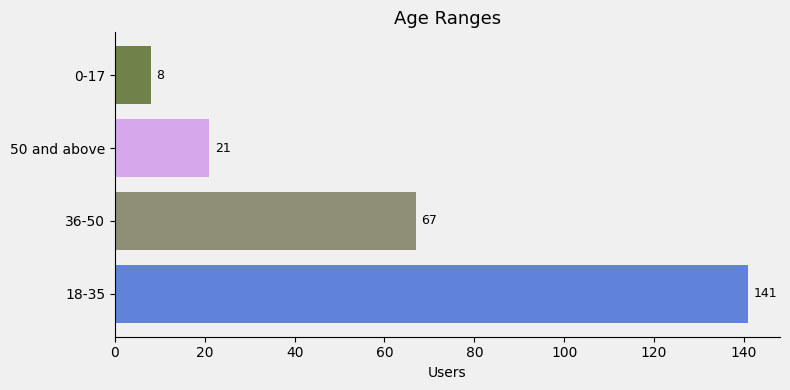

In [55]:
# Question: how does the user base break down by age range/group?
age_ranges = df['Age Ranges'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(age_ranges.index, age_ranges.values, color=bar_colors(len(age_ranges)))
ax.bar_label(ax.containers[0], padding=4, fontsize=9)
ax.set_xlabel('Users')
ax.set_title('Age Ranges', fontsize=13)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()


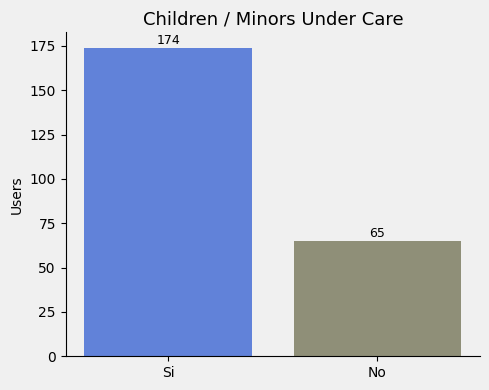

In [56]:
# Question: how many users report having minors (children) under their care?
minors = df['Minors'].value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(minors.index.astype(str), minors.values, color=bar_colors(len(minors)))
ax.set_ylabel('Users')
ax.set_title('Children / Minors Under Care', fontsize=13)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            int(bar.get_height()), ha='center', va='bottom', fontsize=9)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()


## 4. Geography

**What this shows:** *Where* users are and *how settled* they are — the cities with the most users, the mix of recent arrivals vs. long-term residents within each city, and a map of users across Colombia.

**Why it matters:** Location drives operational decisions. Knowing where users cluster helps prioritize which cities need in-person services or locally-tailored content. Layering in how long people have lived there adds nuance: recently-arrived migrants typically need orientation and legal-status help, while long-term residents need ongoing services — so two cities with similar user counts can have very different needs.

> **Technical note.** Cities use `city_display` (main answer + "Otra" free-text merged). The residency-mix chart is a **100% stacked bar** using the normalized `city_duration_clean` buckets, so the *proportion* of recent vs. settled users is comparable across cities regardless of how many were surveyed in each. The map plots one bubble per city at hard-coded centroids, sized by user count; bubble area is a rough visual cue, not a precise scale.

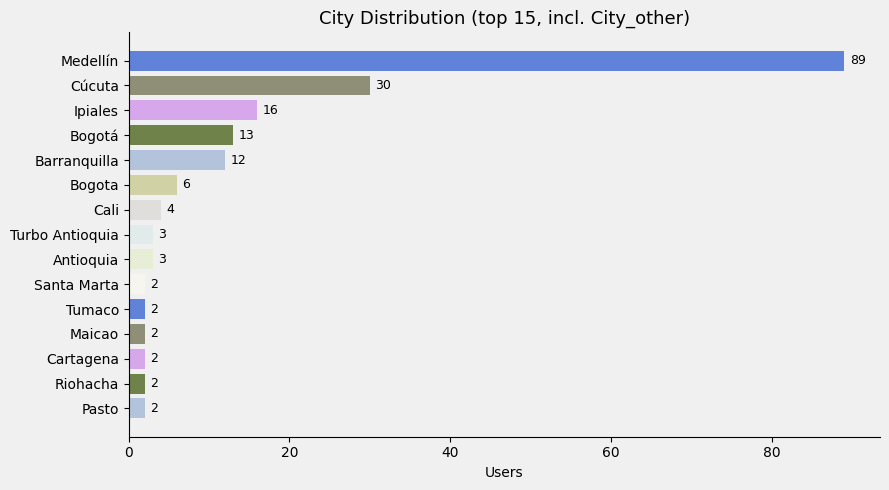

In [57]:
# Question: which cities have the most chatbot users? This tells us where
# the chatbot's audience is geographically concentrated, which is useful
# for prioritizing local partner organizations, services, and content.
city = df['city_display'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(city.index[::-1], city.values[::-1], color=bar_colors(len(city))[::-1])
ax.bar_label(ax.containers[0], padding=4, fontsize=9)
ax.set_xlabel('Users')
ax.set_title('City Distribution (top 15, incl. City_other)', fontsize=13)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()


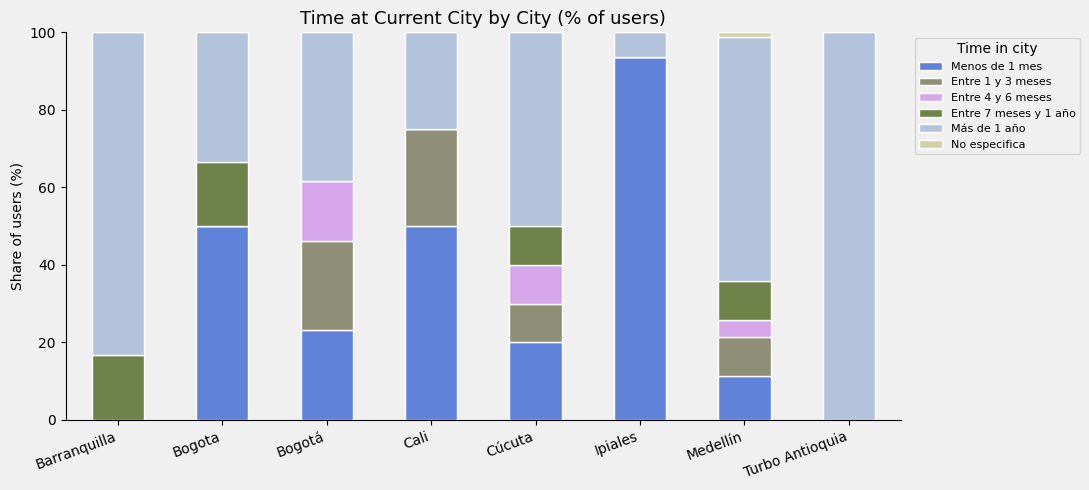

In [58]:
# Question: for each major city, what proportion of users are recent
# arrivals vs long-settled residents? Using `city_duration_clean` (the
# normalized 5-bucket version of City_duration from section 1) and showing
# each city as a 100% stacked bar makes the *mix* directly comparable across
# cities, regardless of how many users were surveyed in each one.
top_cities = df['city_display'].value_counts().head(8).index
cross = (
    df[df['city_display'].isin(top_cities)]
    .dropna(subset=['city_display', 'city_duration_clean'])
    .groupby(['city_display', 'city_duration_clean'])
    .size()
    .unstack(fill_value=0)
)
# Order columns from shortest to longest residency for a readable legend/stack order
cross = cross.reindex(columns=[c for c in DURATION_ORDER if c in cross.columns], fill_value=0)

# Convert counts to row-wise percentages (100% stacked bars)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

dur_colors = bar_colors(cross_pct.shape[1])
ax = cross_pct.plot(kind='bar', stacked=True, color=dur_colors, figsize=(11, 5), edgecolor='white')
plt.title('Time at Current City by City (% of users)', fontsize=13)
plt.xlabel('')
plt.ylabel('Share of users (%)')
plt.legend(title='Time in city', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=20, ha='right')
plt.gca().set_facecolor(CIELO)
plt.gcf().patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()


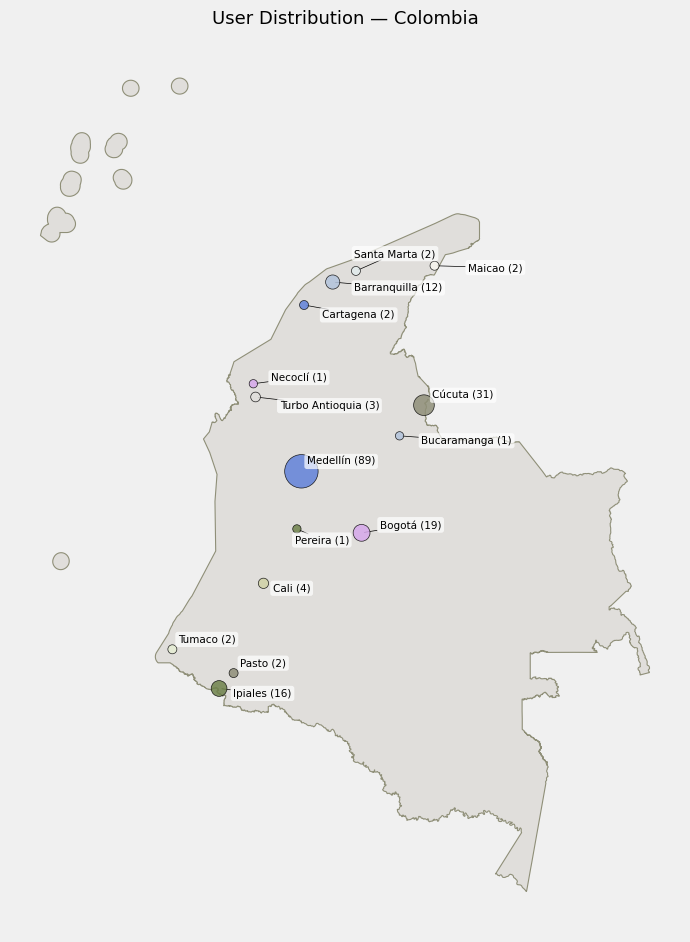

In [59]:
# Question: how is the user base distributed geographically across
# Colombia? Each marker is one city, sized by user count and (per the
# requested style) colored individually using the brand palette cycle so
# nearby cities are easy to tell apart.
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
from adjustText import adjust_text

colombia = ox.geocode_to_gdf("Colombia")

# Hardcoded centroids for all cities appearing in the data (lon, lat)
CITY_COORDS = {
    "Medellín":         (-75.5812, 6.2442),
    "Medellin":         (-75.5812, 6.2442),
    "Cúcuta":           (-72.5078, 7.8939),
    "Cucutá":           (-72.5078, 7.8939),
    "Cucuta":           (-72.5078, 7.8939),
    "Ipiales":          (-77.6453, 0.8297),
    "Necoclí":          (-76.7858, 8.4280),
    "Bogotá":           (-74.0721, 4.7110),
    "Bogota":           (-74.0721, 4.7110),
    "Barranquilla":     (-74.7964, 10.9639),
    "Cali":             (-76.5320, 3.4516),
    "Turbo Antioquia":  (-76.7305, 8.0979),
    "Santa Marta":      (-74.2139, 11.2408),
    "Tumaco":           (-78.8168, 1.8070),
    "Maicao":           (-72.2427, 11.3703),
    "Cartagena":        (-75.5144, 10.3910),
    "Bucaramanga":      (-73.1198, 7.1293),
    "Pereira":          (-75.6942, 4.8087),
    "Armenia":          (-75.6810, 4.5339),
    "Manizales":        (-75.5174, 5.0703),
    "Pasto":            (-77.2811, 1.2136),
    "Villavicencio":    (-73.6354, 4.1420),
}

# Some cities appear under both accented and unaccented spellings
# (e.g. "Bogotá"/"Bogota", "Medellín"/"Medellin", "Cúcuta"/"Cucuta").
# CITY_COORDS maps every spelling to the same point, so without merging
# them first they'd render as two overlapping markers + labels for the
# same city. Canonicalize to one name, then count, so each real city is a
# single bubble carrying its combined user total.
CITY_CANON = {
    "Medellin": "Medellín",
    "Bogota":   "Bogotá",
    "Cucutá":   "Cúcuta",
    "Cucuta":   "Cúcuta",
}
canon = df['city_display'].map(lambda c: CITY_CANON.get(c, c))
city_counts = (
    canon[canon.isin(CITY_COORDS)]
    .value_counts()
    .rename_axis('city_display')
    .reset_index(name='count')
)
city_counts['geometry'] = city_counts['city_display'].map(
    lambda c: Point(CITY_COORDS[c])
)
cities_gdf = gpd.GeoDataFrame(city_counts, geometry='geometry', crs='EPSG:4326')

# Scale bubble size: min 30, max 600
max_count = cities_gdf['count'].max()
cities_gdf['marker_size'] = (cities_gdf['count'] / max_count * 550 + 30).round()

# One distinct palette color per city marker
cities_gdf['color'] = bar_colors(len(cities_gdf))

fig, ax = plt.subplots(figsize=(7, 10))
colombia.to_crs('EPSG:4326').plot(ax=ax, color=HONGO, edgecolor=MADERA, linewidth=0.8)
cities_gdf.plot(
    ax=ax,
    markersize=cities_gdf['marker_size'],
    color=cities_gdf['color'], alpha=0.85,
    edgecolor=NEGRO, linewidth=0.5,
    zorder=3,
)

# Place labels at each city, then let adjustText push them apart so the
# tags (and their "(n users)" counts) no longer overlap each other for
# clustered cities (e.g. the coffee region or the Caribbean coast). Thin
# leader lines connect each displaced label back to its city marker.
texts = [
    ax.text(
        row.geometry.x, row.geometry.y,
        f"{row['city_display']} ({row['count']})",
        fontsize=7.5, color=NEGRO,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.7, edgecolor='none'),
        zorder=4,
    )
    for _, row in cities_gdf.iterrows()
]
adjust_text(
    texts, ax=ax,
    expand=(1.2, 1.5),
    arrowprops=dict(arrowstyle='-', color=NEGRO, lw=0.5),
)

ax.set_title('User Distribution — Colombia', fontsize=13, color=NEGRO, pad=10)
ax.set_axis_off()
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()


## 5. Migration Routes

**What this shows:** The migration journey itself — how long users have been away from their home country, which countries they passed through before reaching Colombia, and where they ultimately hope to go.

**Why it matters:** Sami's users aren't a static population; many are mid-journey. Understanding the routes — who's just left home, who's transiting through, who's trying to reach a further destination — helps the program anticipate needs and coordinate with partner organizations along those corridors.

> **Technical note.** Time-away uses the structured `Away_duration` field. The "previous country" chart relies entirely on free-text `Prev_country_other` (the structured `Prev_country` field is 100% empty), normalized for capitalization so "chile" and "Chile" count together; Colombian nationals — who never crossed a border — are added explicitly as "Colombia" so they aren't silently missing. Destination uses `Destination_Country`.

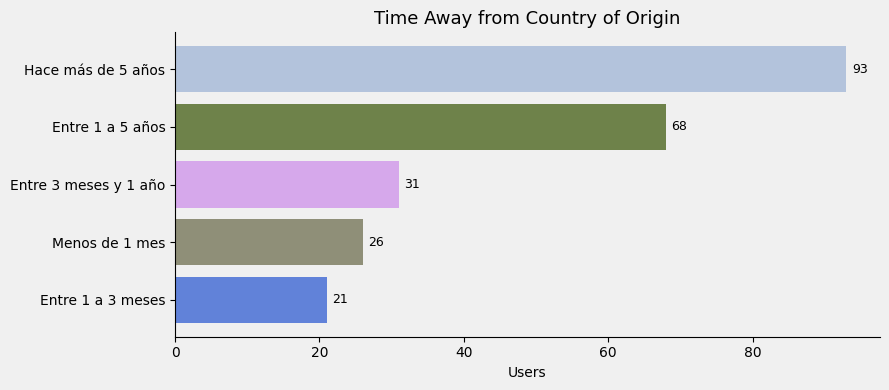

In [60]:
# Question: how long has it been since users left their country of origin?
away = df['Away_duration'].value_counts().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, max(4, len(away) * 0.4)))
ax.barh(away.index, away.values, color=bar_colors(len(away)))
ax.bar_label(ax.containers[0], padding=4, fontsize=9)
ax.set_xlabel('Users')
ax.set_title('Time Away from Country of Origin', fontsize=13)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()


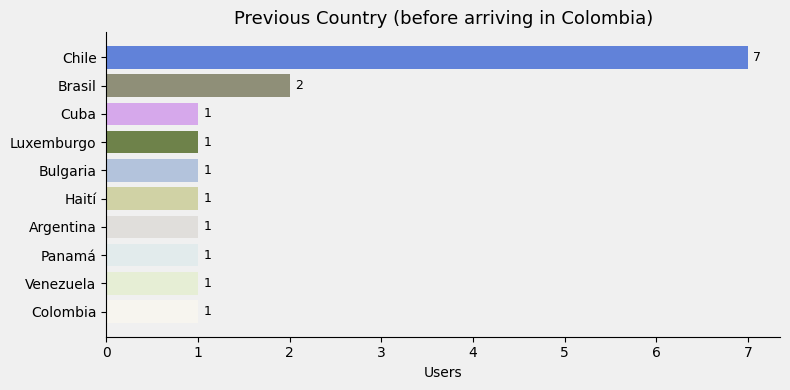

In [61]:
# Question: which countries did users pass through before arriving in
# Colombia? Prev_country (the structured field) is 100% empty, so this
# relies entirely on the free-text Prev_country_other answers, normalized
# for capitalization (e.g. "chile" and "Chile" are the same answer). The
# 1 user whose nationality is Colombian never crossed a border, so their
# "previous country" is Colombia itself -- added here as its own bar so
# Colombia isn't silently absent from this chart.
prev = (
    df['Prev_country_other']
    .dropna()
    .str.strip()
    .str.title()
    .value_counts()
)

n_colombian = (df['nationality_clean'] == 'Colombiana').sum()
if n_colombian:
    prev['Colombia'] = prev.get('Colombia', 0) + n_colombian
    prev = prev.sort_values(ascending=False)

if prev.empty:
    print("No previous country data available.")
else:
    fig, ax = plt.subplots(figsize=(8, max(3, len(prev) * 0.4)))
    ax.barh(prev.index[::-1], prev.values[::-1], color=bar_colors(len(prev))[::-1])
    ax.bar_label(ax.containers[0], padding=4, fontsize=9)
    ax.set_xlabel('Users')
    ax.set_title('Previous Country (before arriving in Colombia)', fontsize=13)
    fig.patch.set_facecolor(CIELO)
    plt.tight_layout()
    plt.show()


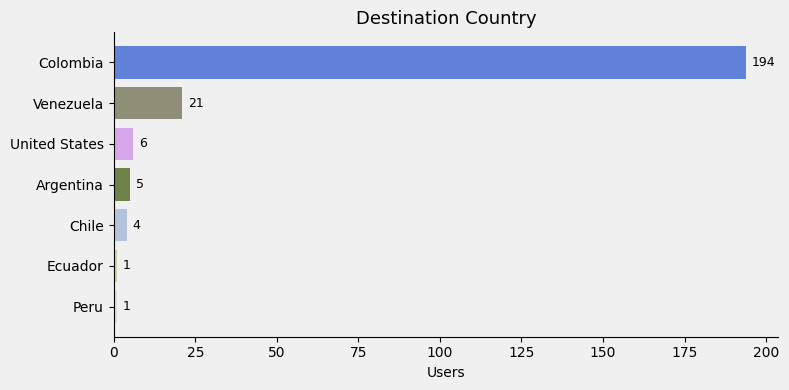

In [62]:
# Question: which country are users ultimately trying to reach?
dest = df['Destination_Country'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(dest.index[::-1], dest.values[::-1], color=bar_colors(len(dest))[::-1])
ax.bar_label(ax.containers[0], padding=4, fontsize=9)
ax.set_xlabel('Users')
ax.set_title('Destination Country', fontsize=13)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()


## 6. Chatbot Engagement

**What this shows:** *How* users actually interact with Sami — the topics they ask about, how many questions a typical user asks, what share were sent the follow-up survey, and how daily usage has changed over time.

**Why it matters:** This is where we see whether Sami is doing its job. The topic mix shows what people actually need help with (and where content should be strengthened); the questions-per-user distribution shows whether people get a quick answer and leave or stay for a real conversation; and the usage timeline reveals growth, drop-offs, and spikes that often line up with outreach campaigns or external events.

> **Technical note.** Topics come from `Chat_summary`, an LLM-generated free-text field that needs cleaning before counting: one row contains leftover prompt instructions (dropped), some rows separate topics with `''` instead of commas, some are written as hashtags (`#legal_documentation`), and capitalization is inconsistent. `TOPIC_MAP` normalizes everything to 7 canonical categories. Questions-per-user is shown as a **summary table rather than a histogram** because most users ask 0–4 questions, so a histogram would pile almost everything into one or two bins. The usage timeline is a daily resample of `Timestamp`.

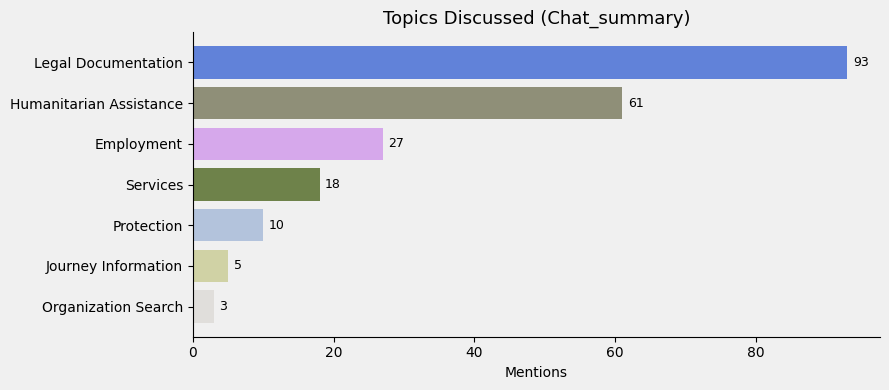

In [63]:
# Question: what topics are users asking the chatbot about?
# Chat_summary is a free-text/LLM-generated field with several
# inconsistencies that need cleaning before counting:
#   - one row contains leftover prompt instructions instead of a topic
#     ("Use exactly one of these hashtags...") and must be dropped
#   - some entries use "''" instead of "," to separate multiple topics
#   - some entries are written as hashtags ("#legal documentation",
#     "#humanitarian_assistance") instead of plain text
#   - capitalization is inconsistent ("Protection" vs "protection")
# TOPIC_MAP normalizes everything down to the 7 canonical topic categories.
TOPIC_MAP = {
    'legal documentation': 'Legal Documentation',
    'humanitarian assistance': 'Humanitarian Assistance',
    'employment': 'Employment',
    'services': 'Services',
    'protection': 'Protection',
    'organization search': 'Organization Search',
    'journey information': 'Journey Information',
}

raw_summaries = df['Chat_summary'].dropna()
raw_summaries = raw_summaries[
    ~raw_summaries.str.contains('Use exactly one of these hashtags', na=False)
]

topics = (
    raw_summaries
    .str.replace("''", ',', regex=False)
    .str.split(',')
    .explode()
    .str.strip()
    .str.lstrip('#')
    .str.replace('_', ' ', regex=False)
    .str.lower()
    .map(TOPIC_MAP)
    .dropna()
    .value_counts()
)

fig, ax = plt.subplots(figsize=(9, max(4, len(topics) * 0.4)))
ax.barh(topics.index[::-1], topics.values[::-1], color=bar_colors(len(topics))[::-1])
ax.bar_label(ax.containers[0], padding=4, fontsize=9)
ax.set_xlabel('Mentions')
ax.set_title('Topics Discussed (Chat_summary)', fontsize=13)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()


In [64]:
# Question: how many questions does a typical user ask in a session?
# A histogram isn't useful here: the vast majority of users ask 0-4
# questions, so almost all of the data lands in 1-2 bins and a handful of
# percentile values can't show meaningful spread. A text summary +
# distribution table communicates this much more clearly.
qs = df['Questions per user'].dropna()

print("Questions per user — summary statistics:")
print(qs.describe().round(2).to_string())
print()

counts = qs.value_counts().sort_index()
summary = pd.DataFrame({
    'Questions asked': counts.index.astype(int),
    'Users': counts.values,
    'Share of users (%)': (counts.values / counts.sum() * 100).round(1),
})
print("Distribution by number of questions asked:")
print(summary.to_string(index=False))


Questions per user — summary statistics:
count    238.00
mean       1.63
std        2.16
min        0.00
25%        0.00
50%        1.00
75%        2.00
max       11.00

Distribution by number of questions asked:
 Questions asked  Users  Share of users (%)
               0     94                39.5
               1     55                23.1
               2     37                15.5
               3     15                 6.3
               4     17                 7.1
               5      3                 1.3
               6      4                 1.7
               7      6                 2.5
               8      2                 0.8
               9      3                 1.3
              11      2                 0.8


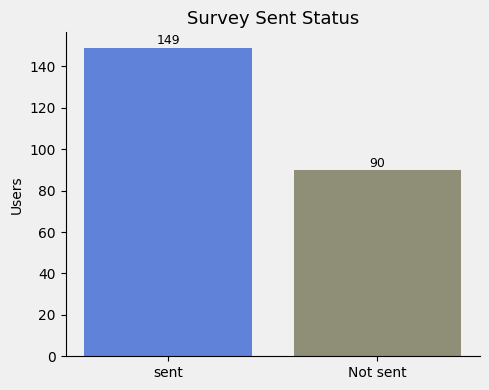

Survey sent rate: 62.3%


In [65]:
# Question: what fraction of users were sent the post-conversation survey?
survey = df['Survey sent'].fillna('Not sent').value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(survey.index, survey.values, color=bar_colors(len(survey)))
ax.set_ylabel('Users')
ax.set_title('Survey Sent Status', fontsize=13)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            int(bar.get_height()), ha='center', va='bottom', fontsize=9)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()
print(f"Survey sent rate: {(survey.get('sent', 0) / survey.sum() * 100):.1f}%")


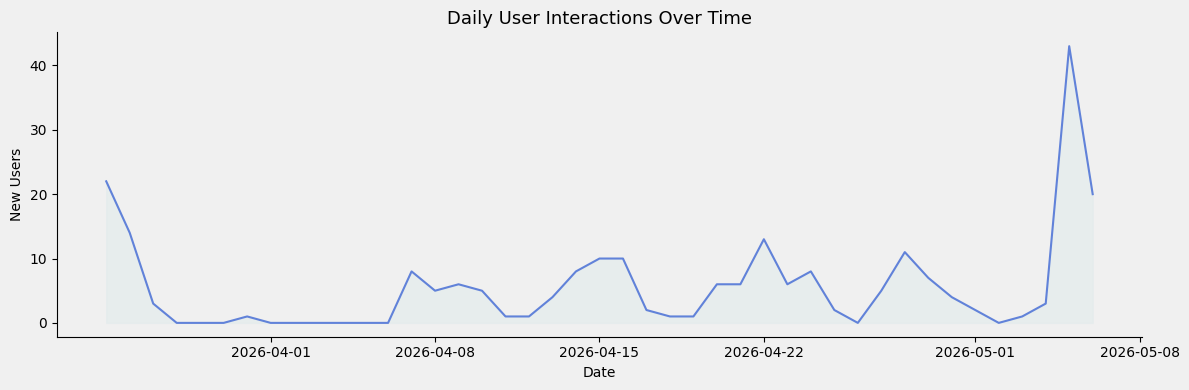

In [66]:
# Question: how has daily chatbot usage evolved over time (growth, drop-offs,
# spikes around specific dates)?
timeline = df.dropna(subset=['Timestamp']).set_index('Timestamp').resample('D').size()
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(timeline.index, timeline.values, color=AGUA_LIGHT, alpha=0.6)
ax.plot(timeline.index, timeline.values, color=AGUA, linewidth=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('New Users')
ax.set_title('Daily User Interactions Over Time', fontsize=13)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()


## 7. Cross-cuts

**What this shows:** Two dimensions at a time, to surface patterns that single-variable charts can't reveal — gender × nationality, average engagement by city, and age by destination country.

**Why it matters:** The most useful insights often live in the *combination* of factors. Whether one nationality skews toward a particular gender, whether some cities have markedly more engaged users, or whether people heading to different countries differ in age — these shape targeted outreach in ways that totals alone never could.

> **Technical note — small samples, careful reading.** With only ~240 users split across several categories, some cells contain very few people. Three guards are built in: the engagement-by-city chart annotates each bar with its sample size (`n=`), so a city averaging 0.0 from just 3 users isn't read with the same confidence as one with 80+; the heatmap uses `PowerNorm(gamma=0.4)` so the single largest cell (Mujer × Venezuela) doesn't wash every other cell to near-white; and charts are limited to the top categories for readability. Treat thin cells as suggestive, not conclusive.

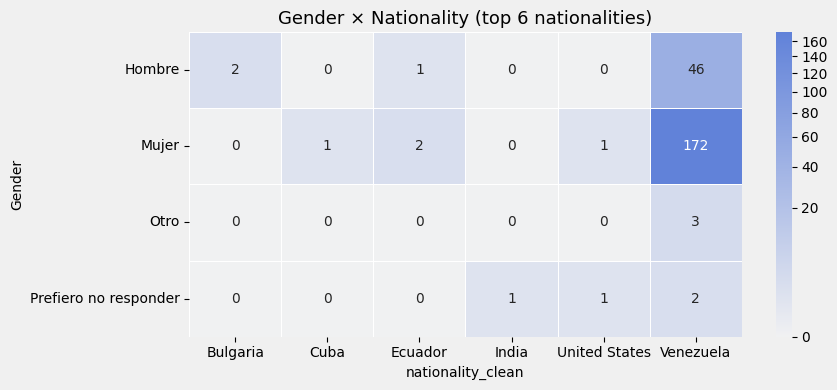

In [67]:
# Question: how do gender and nationality intersect (e.g. is one
# nationality more skewed toward a particular gender than others)?
# Keep top nationalities for readability
top_nat = df['nationality_clean'].value_counts().head(6).index
cross_gn = (
    df[df['nationality_clean'].isin(top_nat)]
    .dropna(subset=['Gender', 'nationality_clean'])
    .groupby(['Gender', 'nationality_clean'])
    .size()
    .unstack(fill_value=0)
)
if cross_gn.empty or cross_gn.size == 0:
    print("Not enough paired data for Gender × Nationality heatmap.")
else:
    cmap = sns.light_palette(AGUA, as_cmap=True)
    # A linear color scale is dominated by the single largest cell (Mujer x
    # Venezuela), leaving almost every other cell near-white. PowerNorm with
    # gamma < 1 compresses the high end and expands the low end of the scale,
    # so smaller counts are still visibly shaded.
    norm = PowerNorm(gamma=0.4, vmin=0, vmax=cross_gn.values.max())
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(cross_gn, annot=True, fmt='d', cmap=cmap, norm=norm,
                linewidths=0.5, linecolor='white', ax=ax, cbar=True)
    ax.set_title('Gender × Nationality (top 6 nationalities)', fontsize=13)
    plt.tight_layout()
    plt.show()


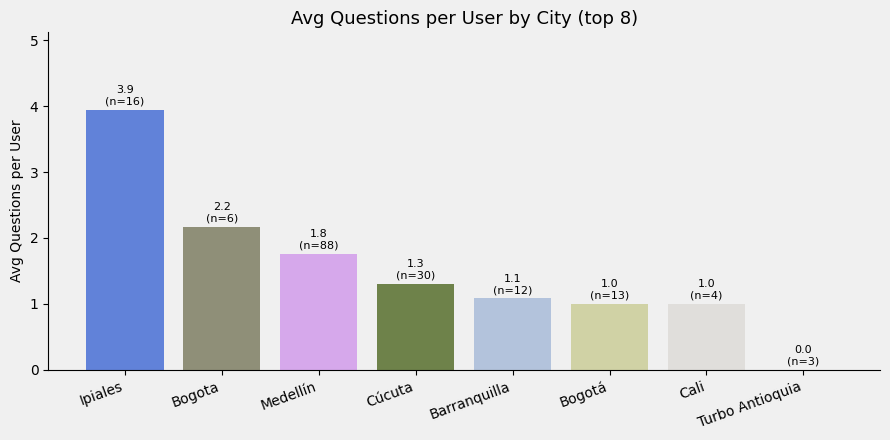

In [68]:
# Question: which cities have the most engaged users (questions asked per
# user)? Each bar is annotated with "n=" (the number of users behind that
# average) so a city like Turbo Antioquia, where the average is 0.0 from
# only 3 users, isn't read with the same confidence as a city with 80+ users.
top_cities = df['city_display'].value_counts().head(8).index
city_eng = (
    df[df['city_display'].isin(top_cities)]
    .groupby('city_display')['Questions per user']
    .agg(mean='mean', n='count')
    .sort_values('mean', ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(city_eng.index, city_eng['mean'], color=bar_colors(len(city_eng)))
for bar, n in zip(ax.patches, city_eng['n']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f"{bar.get_height():.1f}\n(n={n})", ha='center', va='bottom', fontsize=8)
ax.set_ylim(0, city_eng['mean'].max() * 1.3)
ax.set_ylabel('Avg Questions per User')
ax.set_title('Avg Questions per User by City (top 8)', fontsize=13)
ax.set_xticklabels(city_eng.index, rotation=20, ha='right')
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()


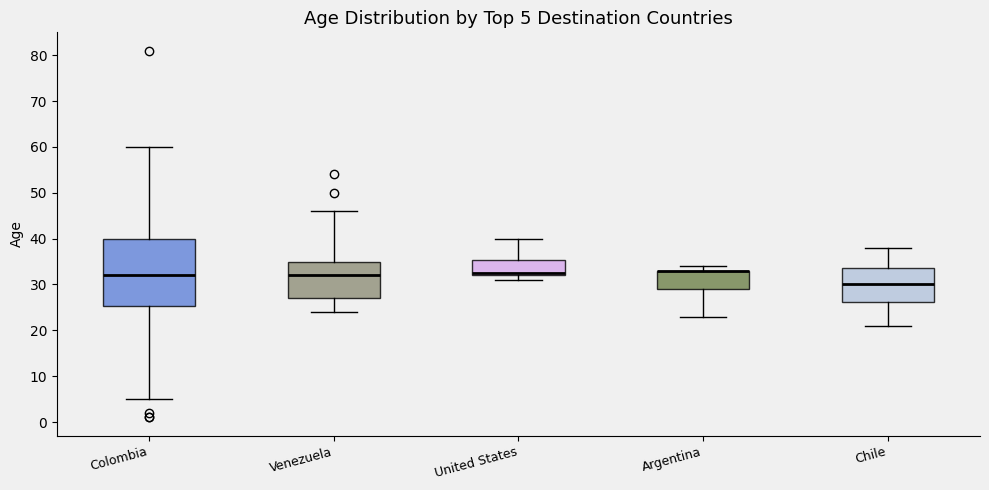

In [69]:
# Question: does the age profile of users differ depending on which
# country they're trying to reach (e.g. are users heading to the US/Chile
# systematically younger or older than those staying in Colombia)?
top_dests = df['Destination_Country'].value_counts().head(5).index.tolist()
subset = df[df['Destination_Country'].isin(top_dests)]
groups = [subset[subset['Destination_Country'] == d]['Age'].dropna().values
          for d in top_dests]
groups = [(g if len(g) > 0 else np.array([np.nan])) for g in groups]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(groups, patch_artist=True, vert=True,
                medianprops=dict(color=NEGRO, linewidth=2))
box_colors = bar_colors(len(top_dests))
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xticklabels(top_dests, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Age')
ax.set_title('Age Distribution by Top 5 Destination Countries', fontsize=13)
fig.patch.set_facecolor(CIELO)
plt.tight_layout()
plt.show()
